In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : 12}

plt.rc('font', **font)
plot_fs = 12

plt.rc('font', family='serif', serif='Times')
plt.rc('text', usetex=True)
plt.rc('xtick', labelsize=9)
plt.rc('ytick', labelsize=9)
plt.rc('axes', labelsize=10)
mpl.rcParams['lines.dashed_pattern'] = [2, 2]
mpl.rcParams['lines.linewidth'] = 1.0

import pathlib
cur_dir = pathlib.Path().cwd()
parent_dir = cur_dir.parent

import sys
print(sys.version)
sys.path.append('../')

from models.powertrain.bounded_powertrain import Bounded_powertrain
from models.kinematic.ideal_diff_drive import Ideal_diff_drive
from models.learning.blr_slip import SlipBayesianLinearRegression, FullBodySlipBayesianLinearRegression
from models.learning.blr_slip_acceleration import SlipAccelerationBayesianLinearRegression, FullBodySlipAccelerationBayesianLinearRegression
from models.kinematic.ICR_based import *
from models.kinematic.Perturbed_unicycle import *
from models.kinematic.enhanced_kinematic import *
from NicolasSamson.script.extractors import * 
from util.transform_algebra import *
from util.util_func import *
from data_utils.dataset_parser import *


import matplotlib.animation as animation
from matplotlib.backend_bases import KeyEvent

3.10.12 (main, Jul 19 2024, 11:05:56) [GCC 11.4.0]


In [2]:
surface_type = 'gravel'

if surface_type == 'gravel':
    path_2_dataset = '../NicolasSamson/drive_datasets/warthog/wheels/ice/ral2023/model_training_datasets/acceleration_dataset.pkl'
    global_save_path_ = '../NicolasSamson/analysis_why_metric/gravel'
    color_background = "lightgrey"

if surface_type == 'ice':
    path_2_dataset = '../NicolasSamson/drive_datasets/warthog/wheels/gravel/ral2023/model_training_datasets/acceleration_dataset.pkl'
    global_save_path_ = '../NicolasSamson/analysis_why_metric/ice'
    color_background = "lightblue"

df_acceleration = pd.read_pickle(path_2_dataset)

print_column_unique_column(df_acceleration)
print(df_acceleration.shape)




['init_icp_x' 'init_icp_y' 'init_icp_z' 'init_icp_roll' 'init_icp_pitch'
 'init_icp_yaw' 'calib_step' 'cmd_left' 'cmd_right' 'left_wheel_vel'
 'right_wheel_vel' 'icp_x' 'icp_y' 'icp_z' 'icp_roll' 'icp_pitch'
 'icp_yaw' 'imu_yaw' 'icp_vx' 'icp_vy' 'icp_omega' 'steady_state_mask'
 'transitory_state_mask' 'imu_acceleration_x' 'imu_acceleration_y'
 'imu_acceleration_z' 'gt_icp_x' 'gt_icp_y' 'gt_icp_z' 'gt_icp_roll'
 'gt_icp_pitch' 'gt_icp_yaw' 'transitory_vel_left' 'transitory_vel_right'
 'idd_vel_x' 'idd_vel_y' 'idd_vel_yaw' 'icp_interpolated_x'
 'icp_interpolated_y' 'icp_interpolated_yaw'
 'icp_corrected_interpolated_x' 'icp_corrected_interpolated_y' 'icp_vel_x'
 'icp_vel_y' 'icp_vel_yaw' 'body_vel_disturption_x'
 'body_vel_disturption_y' 'body_vel_disturption_yaw' 'idd_acceleration_x'
 'idd_acceleration_y' 'idd_acceleration_yaw' 'icp_acceleration_x'
 'icp_acceleration_y' 'icp_acceleration_yaw']
(591, 1458)


In [4]:
df_all_combined = pd.read_pickle("/home/nicolassamson/workspaces/norlab_WMRD/NicolasSamson/drive_datasets/all_terrain_diamond_shape_graph_data.pkl")

df_all_combined_gravel = df_all_combined.loc[df_all_combined["terrain"] == "gravel"]

print(df_all_combined_gravel.shape)

(197, 14)


In [5]:
def reshape_into_6sec_windows(column_to_reshape, n_window=3):

    first_index = column_to_reshape.shape[0]//n_window
    total_info = column_to_reshape.shape[0]* column_to_reshape.shape[1]
    second_size = total_info//first_index
    reshape_size = (first_index, second_size)

    column_to_reshape = column_to_reshape.reshape(reshape_size)

    return column_to_reshape





In [6]:
def update_params(self, new_params):
        self.powetrain_model.update_params(new_params)

def find_max_wheel_vels(self):
    left_min_vel = min(self.dataframe['left_wheel_vel_39'])
    left_max_vel = max(self.dataframe['left_wheel_vel_39'])
    right_min_vel = min(self.dataframe['right_wheel_vel_39'])
    right_max_vel = max(self.dataframe['right_wheel_vel_39'])
    return left_min_vel, left_max_vel, right_min_vel, right_max_vel

def compute_powertrain_error_all_steps(self, init_params):
    self.update_params(init_params)
    # print(init_params)
    wheel_vel_error = 0
    counted_pred_counter = 0

    transitory_state_mask = self.dataframe['transitory_state_mask'].to_numpy() == 1

    if self.wheel_side == 'left':
        self.powetrain_model.min_vel = min(self.dataframe['left_wheel_vel_39'])
        self.powetrain_model.max_vel = max(self.dataframe['left_wheel_vel_39'])
    if self.wheel_side == 'right':
        self.powetrain_model.min_vel = min(self.dataframe['right_wheel_vel_39'])
        self.powetrain_model.max_vel = max(self.dataframe['right_wheel_vel_39'])

    # for i, (inputs, targets, step, encoders, icp_vx, icp_vy, icp_omega, steady_state_mask, transitory_state_mask) in enumerate(self.dataloader):
    for i in range(0, len(self.dataframe)):
        # print(inputs)
        # print(targets)
        if transitory_state_mask[i]:
            if self.wheel_side == 'left':
                # prev_wheel_vel = inputs[0, 6].numpy()
                prev_wheel_vel = self.encoder_left_vels[i, 0]
            if self.wheel_side == 'right':
                # prev_wheel_vel = inputs[0, 7].numpy()
                prev_wheel_vel = self.encoder_right_vels[i, 0]
            cmd_time_elapsed = 0
            # if True:
            for j in range(0, self.timesteps_per_horizon):
                if self.wheel_side == 'left':
                    cmd_wheel_vel = self.cmd_left_vels[i,j]
                if self.wheel_side == 'right':
                    cmd_wheel_vel = self.cmd_right_vels[i,j]

                predicted_wheel_vel = self.powetrain_model.compute_bounded_wheel_vels(cmd_wheel_vel, prev_wheel_vel, cmd_time_elapsed)
                prev_wheel_vel = predicted_wheel_vel
                cmd_time_elapsed += self.dt
                if self.wheel_side == 'left':
                    wheel_vel_error += np.abs(predicted_wheel_vel - self.encoder_left_vels[i,j])
                if self.wheel_side == 'right':
                    wheel_vel_error += np.abs(predicted_wheel_vel - self.encoder_right_vels[i,j])
            # print(horizon_error)
            counted_pred_counter += 1
    # print('total error : ', wheel_vel_error)
    # print('horizons accounted : ', counted_pred_counter)
    return wheel_vel_error

def train_model(self, init_params, method, bounds):
    fun = lambda x: self.compute_powertrain_error_all_steps(x)
    self.wheel_side = 'left'
    left_training_result = minimize(fun, init_params, method=method, bounds=bounds)
    self.wheel_side = 'right'
    right_training_result = minimize(fun, init_params, method=method, bounds=bounds)
    return left_training_result.x, right_training_result.x

In [7]:
y_operation_pontverbose = True
rate = 0.05 #s
nb_timestamp = 120
verbose = True



left_wheel_vel = column_type_extractor(df_acceleration, 'left_wheel_vel',verbose=verbose)
right_wheel_vel = column_type_extractor(df_acceleration, 'right_wheel_vel',verbose=verbose)
icp_vel_x = column_type_extractor(df_acceleration, 'icp_vel_x',verbose=verbose)
icp_vel_yaw = column_type_extractor(df_acceleration, 'icp_vel_yaw',verbose=verbose)
body_vel_icp = np.vstack((icp_vel_x,icp_vel_yaw))


raw_icp_vel_x = column_type_extractor(df_acceleration, 'raw_icp_vel_x',verbose=False)
raw_icp_vel_yaw = column_type_extractor(df_acceleration, 'raw_icp_vel_yaw',verbose=False)
print_column_unique_column(df_acceleration)
column_to_reshape = [left_wheel_vel,right_wheel_vel,
                    icp_vel_x,icp_vel_yaw, body_vel_icp,
                    raw_icp_vel_x,raw_icp_vel_yaw]



for i in range(len(column_to_reshape)):
    column_to_reshape[i] = reshape_into_6sec_windows(column_to_reshape[i], n_window=3)
    

left_wheel_vel,right_wheel_vel, icp_vel_x,icp_vel_yaw, body_vel_icp,raw_icp_vel_x,raw_icp_vel_yaw = column_to_reshape



time_axis = create_time_axe(rate,nb_timestamp)



________left_wheel_vel________
The column type: left_wheel_vel
The resulting dataframe_shape: (591, 40)
Number of calibrating steps:591
Number of measurement by step: 40
Maximum 12.941616403537953
Minimum -13.041972835527627
______________________________
________right_wheel_vel________
The column type: right_wheel_vel
The resulting dataframe_shape: (591, 40)
Number of calibrating steps:591
Number of measurement by step: 40
Maximum 12.919799787888024
Minimum -12.705996954518719
_______________________________
________icp_vel_x________
The column type: icp_vel_x
The resulting dataframe_shape: (591, 40)
Number of calibrating steps:591
Number of measurement by step: 40
Maximum 2.711354718615302
Minimum -3.478417039510205
_________________________
________icp_vel_yaw________
The column type: icp_vel_yaw
The resulting dataframe_shape: (591, 40)
Number of calibrating steps:591
Number of measurement by step: 40
Maximum 2.755186351506815
Minimum -3.3384444392036343
___________________________


In [8]:
# compute the cmds 
cmd_left_all = column_type_extractor(df_acceleration, 'cmd_l',verbose=False)
cmd_right_all = column_type_extractor(df_acceleration, 'cmd_r',verbose=False)





# Compute the body vel 
cmd_body_vel_yaw_all = []
cmd_body_vel_x_all = []

print(cmd_right_all.shape)
n_step = cmd_left_all.shape[0] 
horizon_length = cmd_left_all.shape[1]
total_info = n_step * horizon_length
final_shape = ( total_info//(horizon_length *3), horizon_length *3)

for calib_step in range(n_step):
    for i in range(horizon_length): 
        cmd_vel_wheel_i = np.array([cmd_left_all[calib_step,i],cmd_right_all[calib_step,i]])
    
        body_vel_i = compute_body_vel_IDD(cmd_vel_wheel_i , robot='warthog-wheel')
        cmd_body_vel_yaw_all.append(body_vel_i[1])
        cmd_body_vel_x_all.append(body_vel_i[0])

# The computed body vel reshape 
cmd_body_vel_x_all = np.array(cmd_body_vel_x_all).reshape(final_shape)
cmd_body_vel_yaw_all = np.array(cmd_body_vel_yaw_all).reshape(final_shape)
cmd_left_all_reshape = cmd_left_all.reshape(final_shape)
cmd_right_all_reshape = cmd_right_all.reshape(final_shape)



(591, 40)


In [9]:
# Calculate the y normalized and centered. 
normalized_left_wheel,normalized_cmd_left_all_reshape = normalizer_2d_array(left_wheel_vel,cmd_left_all_reshape)
normalized_right_wheel_vel,normalized_cmd_right_all_reshape = normalizer_2d_array(right_wheel_vel,cmd_right_all_reshape)
normalized_icp_vel_x, noramilzed_cmd_body_vel_x_all = normalizer_2d_array(icp_vel_x, cmd_body_vel_x_all)
normalized_icp_vel_yaw, normalized_cmd_body_vel_yaw_all = normalizer_2d_array(icp_vel_yaw, cmd_body_vel_yaw_all)




(197, 120)
(197, 120)
(197, 120)
(197, 120)


In [10]:
def compute_time_cst_gain_delay_step_operation_points(df_slip,name_column_interest, name_column_cmd,rate,nb_timestamp, n_window = 3,verbose=False):
    """Compute the time_constant, time_delay, gains.

    Args:
        df_slip (df): _description_
        name_column_interest (str): _description_
        name_column_cmd (str): _description_
        n_window (int, optional): _description_. Defaults to 3.
        verbose (bool, optional): _description_. Defaults to False.
    """
    column_of_interest = column_type_extractor(df_slip, name_column_interest,verbose=verbose)
    column_interest_reshape = reshape_into_6sec_windows(column_of_interest, n_window=n_window)
    

    cmd_of_interest = column_type_extractor(df_slip, name_column_cmd,verbose=verbose)
    cmd_of_interest_reshape = reshape_into_6sec_windows(cmd_of_interest, n_window=n_window)

    operation_point_interest,steps_cmd_interest_reshape = compute_operation_points_and_step(column_interest_reshape,cmd_of_interest_reshape)

    #
    time_axis = create_time_axe(rate,nb_timestamp)
    first_order_model = FirstOrderModelWithDelay(1,1,rate)
    step_y_interest_centered = left_wheel_vel-operation_point_interest
    gains_computed, time_constants_computed, time_delay_computed,predictions = first_order_model.train_all_calib_state(time_axis,steps_cmd_interest_reshape,step_y_interest_centered,operation_point_interest)

    predictions_error = np.sum(np.abs(predictions-column_of_interest)) 
    # Create a second dataframe 

    df_2_add = {name_column_interest+"_gains":gains_computed,
                name_column_interest+"_time_constants":time_constants_computed,
                name_column_interest+"_time_delay":time_delay_computed,
                name_column_interest+"_predictions_sum_abs":predictions_error,

                }
    


In [11]:
# Computed te operation point and the steps 
operation_point_left_wheel,steps_cmd_left_all_reshape = compute_operation_points_and_step(left_wheel_vel,cmd_left_all_reshape)
operation_point_right_wheel_vel,steps_cmd_right_all_reshape = compute_operation_points_and_step(right_wheel_vel,cmd_right_all_reshape)
operation_point_icp_vel_x, steps_cmd_body_vel_x_all = compute_operation_points_and_step(icp_vel_x, cmd_body_vel_x_all)
operation_point_icp_vel_yaw, steps_cmd_body_vel_yaw_all = compute_operation_points_and_step(icp_vel_yaw, cmd_body_vel_yaw_all)



(197, 120)
(197, 120)
(197, 120)
(197, 120)


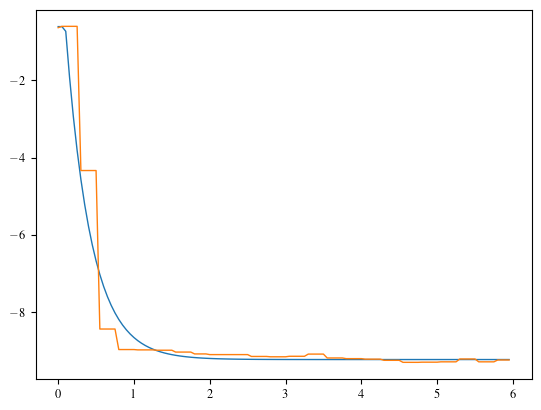

In [12]:
# ccomputed the time constant 

first_model = FirstOrderModelWithDelay(1,1,rate)
step_y_left_wheeleft_wheel_vell_vel_centered = left_wheel_vel-operation_point_left_wheel
#gains_computed, time_constants_computed, time_delay_computed = first_model.train_all_calib_state(time_axis,steps_cmd_left_all_reshape,step_y_left_wheeleft_wheel_vell_vel_centered)

i = 5
gains_computed, time_constants_computed,time_delay_computed = first_model.train(time_axis,steps_cmd_left_all_reshape[i], step_y_left_wheeleft_wheel_vell_vel_centered[i,:])
y_pred = first_model.ypred(operation_point_left_wheel[i,:])

fig, axs = plt.subplots(1,1)


axs.plot(time_axis,y_pred,label="prediction")
axs.plot(time_axis,left_wheel_vel[i,:],label="ground_truth")





In [13]:
first_model = FirstOrderModelWithDelay(1,1,rate)
step_y_left_wheeleft_wheel_vell_vel_centered = left_wheel_vel-operation_point_left_wheel
gains_computed, time_constants_computed, time_delay_computed,predictions = first_model.train_all_calib_state(time_axis,steps_cmd_left_all_reshape,step_y_left_wheeleft_wheel_vell_vel_centered,operation_point_left_wheel)

print(predictions)

/home/nicolassamson/workspaces/norlab_WMRD/NicolasSamson/../NicolasSamson/script/extractors.py:120: RuntimeWarning: overflow encountered in square
  iae = sum(abs(z-y)**2)
/home/nicolassamson/.pyenv/versions/data_analysis/lib/python3.10/site-packages/scipy/optimize/_numdiff.py:592: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0
/home/nicolassamson/workspaces/norlab_WMRD/NicolasSamson/../NicolasSamson/script/extractors.py:120: RuntimeWarning: overflow encountered in square
  iae = sum(abs(z-y)**2)
/home/nicolassamson/.pyenv/versions/data_analysis/lib/python3.10/site-packages/scipy/optimize/_numdiff.py:592: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0
/home/nicolassamson/workspaces/norlab_WMRD/NicolasSamson/../NicolasSamson/script/extractors.py:120: RuntimeWarning: overflow encountered in square
  iae = sum(abs(z-y)**2)
/home/nicolassamson/.pyenv/versions/data_analysis/lib/python3.10/site-packages/scipy/optimize/_numdiff.py:592: Run

[[  0.           0.           0.         ...  -9.57309478  -9.57313748
   -9.57317646]
 [ -9.20573914  -9.20573914  -9.20573914 ...  10.609797    10.60981522
   10.60983162]
 [ 10.22675675  10.22675675  10.22675675 ...  -9.44449979  -9.44452436
   -9.44454657]
 ...
 [-11.91623547 -11.91623547 -11.91623547 ... -11.91623546 -11.91623546
  -11.91623546]
 [-11.91623547 -11.91623547 -11.91623547 ... -11.91623547 -11.91623547
  -11.91623547]
 [-11.91623547 -11.91623547 -11.91623547 ... -11.91623541 -11.91623541
  -11.91623541]]


/home/nicolassamson/workspaces/norlab_WMRD/NicolasSamson/../NicolasSamson/script/extractors.py:120: RuntimeWarning: overflow encountered in square
  iae = sum(abs(z-y)**2)
/home/nicolassamson/.pyenv/versions/data_analysis/lib/python3.10/site-packages/scipy/optimize/_numdiff.py:592: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0
/home/nicolassamson/workspaces/norlab_WMRD/NicolasSamson/../NicolasSamson/script/extractors.py:115: RuntimeWarning: overflow encountered in exp
  return np.array([K*(1-np.exp(-(time-tau_d)/tau)) if time >= tau_d else 0 for time in t])
/home/nicolassamson/workspaces/norlab_WMRD/NicolasSamson/../NicolasSamson/script/extractors.py:120: RuntimeWarning: overflow encountered in square
  iae = sum(abs(z-y)**2)
/home/nicolassamson/workspaces/norlab_WMRD/NicolasSamson/../NicolasSamson/script/extractors.py:120: RuntimeWarning: overflow encountered in square
  iae = sum(abs(z-y)**2)
/home/nicolassamson/workspaces/norlab_WMRD/NicolasSamson/../Nico

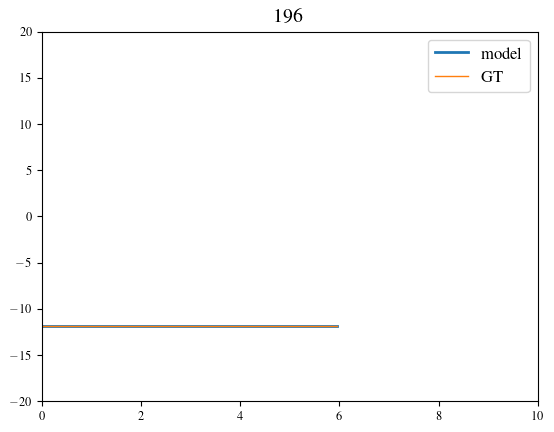

In [14]:

# Initialize data
data = {'x': [], 'y': []}

# Create a figure and axis
fig, ax = plt.subplots()
line, = ax.plot([], [], lw=2,label ="model")
line2, = ax.plot([],[],label = "GT")

# Set up the plot limits
ax.set_xlim(0, 10)
ax.set_ylim(-20, 20)
ax.legend()

# Initialize animation data
def init():
    line.set_data([], [])
    return line,

# Update the line data
def update(anim_i):
    line.set_data(time_axis, predictions[anim_i,:])
    line2.set_data(time_axis, left_wheel_vel[anim_i,:])
    #ax.set_title(f"time constant {time_constants_computed[anim_i]} \n time_delay {time_delay_computed} \n gains {gains_computed} ")
    ax.set_title(f"{anim_i}")
    return line,line2

# Function to handle key presses

# Create the animation
ani = animation.FuncAnimation(
    fig,
    update,
    frames=range(10),
    init_func=init,
    blit=True,
    interval=1000  # Update interval in milliseconds
)

ani = animation.FuncAnimation(fig, update, init_func=init, frames=predictions.shape[0], interval=1000, blit=True)

# Save the animation as a video
ani.save('sine_wave_animation.mp4', writer='ffmpeg')


In [15]:
print(np.median(gains_computed))
print(np.median(time_constants_computed))
print(np.median(time_delay_computed))



0.9685811519095539
0.31625772039364547
0.29723393770486345


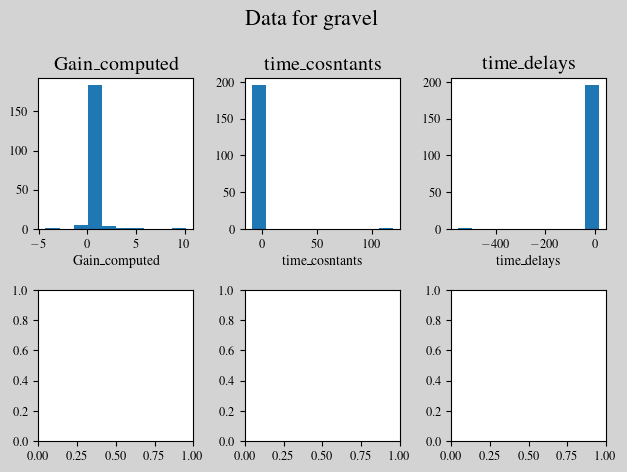

In [16]:
fig, axs = plt.subplots(2,3)


axs[0][0].hist(gains_computed,label="gain_computed")

axs[0][1].hist(time_constants_computed,label="time_constants")

axs[0][2].hist(time_delay_computed,label="time_delay")




axs[0][0].set_title("Gain_computed")
axs[0][1].set_title("time_cosntants")
axs[0][2].set_title("time_delays")

axs[0][0].set_xlabel("Gain_computed")
axs[0][1].set_xlabel("time_cosntants")
axs[0][2].set_xlabel("time_delays")



y_min = 0
y_max = 3
#axs[0][0].set_xlim((y_min,y_max))
#axs[0][1].set_xlim((y_min,y_max))
#axs[0][2].set_xlim((y_min,y_max))
#axs[1][1].set_ylim((y_min,y_max))
fig.suptitle(f"Data for {surface_type}",fontsize=16)

fig.patch.set_facecolor(color_background)

fig.tight_layout()


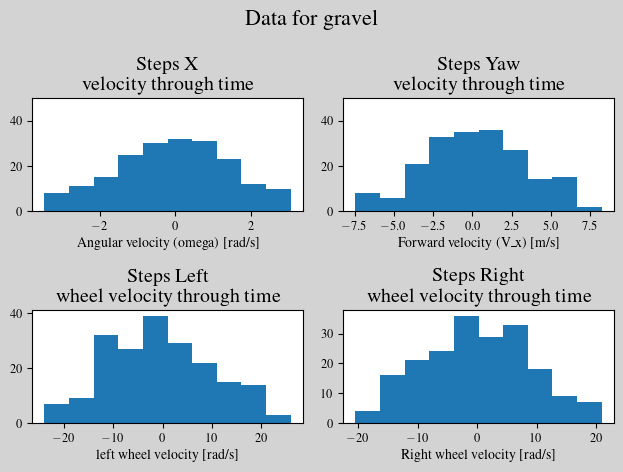

In [17]:



fig, axs = plt.subplots(2,2)


axs[0][0].hist(steps_cmd_body_vel_x_all,label="ICP_raw")
axs[0][1].hist(steps_cmd_body_vel_yaw_all,label="ICP_raw")


axs[1][1].hist(steps_cmd_right_all_reshape,label="wheel odometry")
axs[1][0].hist(steps_cmd_left_all_reshape,label="wheel odometry")

axs[0][0].set_title("Steps X \n velocity through time")
axs[0][1].set_title("Steps Yaw \n velocity through time")
axs[1][0].set_title("Steps Left \n wheel velocity through time")
axs[1][1].set_title("Steps Right \n wheel velocity through time")

axs[0][0].set_xlabel("Angular velocity (omega) [rad/s]")
axs[0][1].set_xlabel("Forward velocity (V_x) [m/s]")

axs[1][0].set_xlabel("left wheel velocity [rad/s]")
axs[1][1].set_xlabel("Right wheel velocity [rad/s]")


y_min = 0
y_max = 50
axs[0][0].set_ylim((y_min,y_max))
axs[0][1].set_ylim((y_min,y_max))
#axs[1][0].set_ylim((y_min,y_max))
#axs[1][1].set_ylim((y_min,y_max))
fig.suptitle(f"Data for {surface_type}",fontsize=16)

fig.patch.set_facecolor(color_background)

fig.tight_layout()


